# Evaluating the Performance of a Support Vector Machine (SVM) Model 🚀

In this notebook, we will explore the evaluation process of a **Support Vector Machine (SVM)** model. SVM is a powerful classification algorithm that identifies the optimal hyperplane to separate data points into different classes.

## Key Objectives 🎯:
- **Model Evaluation**: We will assess how well the SVM model performs in terms of accuracy, precision, recall, and F1 score.
- **Performance Metrics 📊**: Using visualizations such as confusion matrices and classification reports to understand the model's strengths and areas for improvement.

Let's dive into the details and evaluate the model's performance effectively! 🔍


### includes

In [1]:

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve, confusion_matrix,accuracy_score
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sn

### loading dataset

In [4]:
df=pd.read_csv('../../dataset/diabetes_dataset.csv')
df.head()


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [4]:
df.describe

<bound method NDFrame.describe of        year  gender   age location  race:AfricanAmerican  race:Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disease  \
0                   

In [5]:
df.columns

Index(['year', 'gender', 'age', 'location', 'race:AfricanAmerican',
       'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other',
       'hypertension', 'heart_disease', 'smoking_history', 'bmi',
       'hbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [13]:
## we drop the unnessessary information
df.drop(columns=['year','location','race:AfricanAmerican','race:Asian','race:Caucasian','race:Hispanic','race:Other','smoking_history'],inplace=True)
df

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
0,Female,32.0,0,0,27.32,5.0,100,0
1,Female,29.0,0,0,19.95,5.0,90,0
2,Male,18.0,0,0,23.76,4.8,160,0
3,Male,41.0,0,0,27.32,4.0,159,0
4,Female,52.0,0,0,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...
99995,Female,33.0,0,0,21.21,6.5,90,0
99996,Female,80.0,0,0,36.66,5.7,100,0
99997,Male,46.0,0,0,36.12,6.2,158,0
99998,Female,51.0,0,0,29.29,6.0,155,0


### Data Preprocessing

### Label Encoding

`LabelEncoder` is a preprocessing technique used to convert **categorical text data** into **numerical labels**. It is useful for machine learning algorithms that can only work with numerical values.





In [14]:
encoder = LabelEncoder()
df['gender'] = encoder.fit_transform(df['gender'])

label_mapping = dict(zip(encoder.classes_, range(len(encoder.classes_))))

print("Label Encoding Mapping:", label_mapping)


Label Encoding Mapping: {'Female': 0, 'Male': 1, 'Other': 2}


In [8]:
df.tail()

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
99995,0,33.0,0,0,21.21,6.5,90,0
99996,0,80.0,0,0,36.66,5.7,100,0
99997,1,46.0,0,0,36.12,6.2,158,0
99998,0,51.0,0,0,29.29,6.0,155,0
99999,1,13.0,0,0,17.16,5.0,90,0


### Data Cleaning

`Data Cleaning` is the process of detecting, correcting, or removing inaccurate, incomplete, or irrelevant parts of the data. This is a crucial step in data preprocessing to ensure the quality and reliability of the data before analysis or modeling.

#### Common Data Cleaning Tasks:

- **Handling Missing Values**
  - Remove rows or columns with too many missing values.
  - Fill missing values with mean, median, mode, or use interpolation.
  
- **Removing Duplicates**
  - Identify and drop duplicate records to avoid bias.

In [15]:
## for data cleaning (removing nulls and duplicate values)
df.drop_duplicates(inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 91313 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               91313 non-null  int32  
 1   age                  91313 non-null  float64
 2   hypertension         91313 non-null  int64  
 3   heart_disease        91313 non-null  int64  
 4   bmi                  91313 non-null  float64
 5   hbA1c_level          91313 non-null  float64
 6   blood_glucose_level  91313 non-null  int64  
 7   diabetes             91313 non-null  int64  
dtypes: float64(3), int32(1), int64(4)
memory usage: 5.9 MB
None


In [17]:
## removing of missing values 
df = df.drop(df[df['gender'] == 2].index)
df.shape

(91295, 8)

### Data Normalization

To put all the variables on the same scale, we normalized the data to a range of 0–1 using the following equation:


Where:  
- `x*` = normalized value  
- `X` = original value  
- `min(x)` = minimum value of the dataset  
- `max(x)` = maximum value of the dataset  

This normalization ensures that all features contribute equally to the analysis.


In [18]:
## normalizing of the dataset

# Select columns to normalize
cols_to_normalize = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

# Initialize scaler and apply normalization
scaler = MinMaxScaler()
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

print(df.tail())

       gender       age  hypertension  heart_disease       bmi  hbA1c_level  \
99995       0  0.411912             0              0  0.130719     0.545455   
99996       0  1.000000             0              0  0.311041     0.400000   
99997       1  0.574575             0              0  0.304739     0.490909   
99998       0  0.637137             0              0  0.225023     0.454545   
99999       1  0.161662             0              0  0.083450     0.272727   

       blood_glucose_level  diabetes  
99995             0.045455         0  
99996             0.090909         0  
99997             0.354545         0  
99998             0.340909         0  
99999             0.045455         0  


## 📊 some visualizations

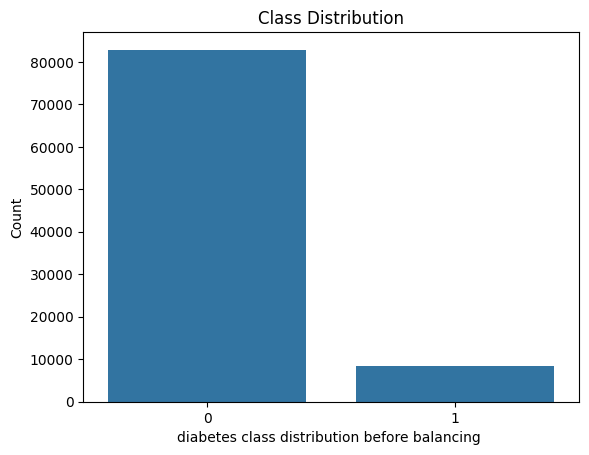

In [19]:
import seaborn as sns
sns.countplot(data=df, x='diabetes')
plt.title('Class Distribution')
plt.xlabel('diabetes class distribution before balancing ')
plt.ylabel('Count')
plt.show()

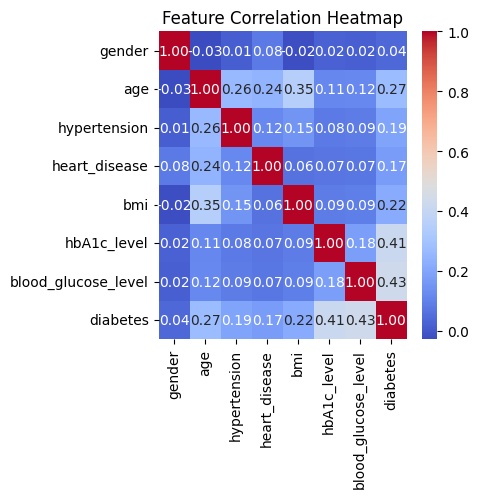

In [23]:
plt.figure(figsize=(4, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

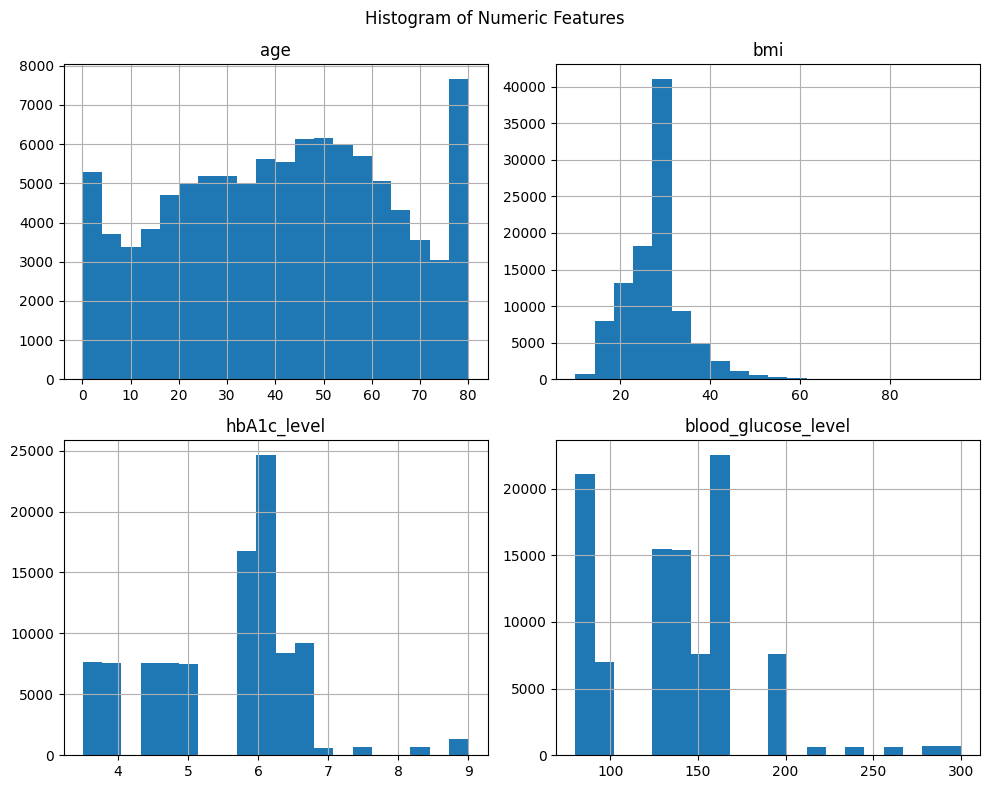

In [7]:
numeric_features = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

df[numeric_features].hist(figsize=(10, 8), bins=20)
plt.suptitle('Histogram of Numeric Features')
plt.tight_layout()
plt.show()

# Train-Test Split

The **train-test split** is a method used in machine learning to evaluate the performance of a model. It involves splitting the available dataset into two separate subsets: one for training the model and one for testing its performance.





In [25]:
## splitting the dataset 
from imblearn.over_sampling import SMOTE
x=df.drop(columns=['diabetes'])
y=df['diabetes']
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(X_train['gender'])


0         1
1         0
2         0
3         1
4         1
         ..
132673    0
132674    0
132675    0
132676    0
132677    1
Name: gender, Length: 132678, dtype: int32


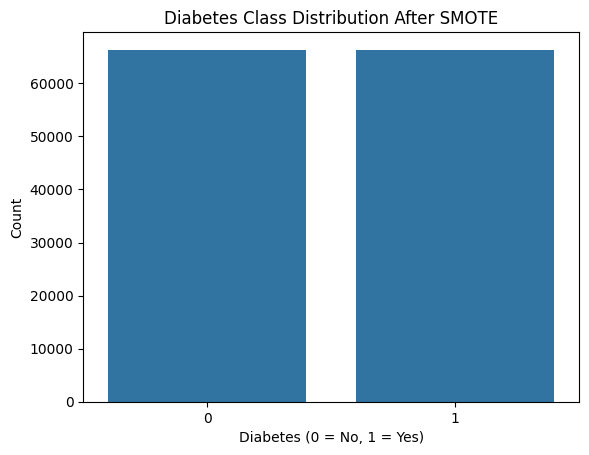

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train)
plt.title('Diabetes Class Distribution After SMOTE')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Entropy in Information Theory

Entropy is a fundamental concept in information theory, introduced by Claude Shannon in 1948. It measures the **uncertainty** or **disorder** within a dataset or system. In machine learning and classification, it is often used to evaluate how **mixed** or **pure** a set of labels is.

### Key Points:
- **High entropy** means there is **high uncertainty** (more randomness or disorder).
- **Low entropy** means there is **low uncertainty** (more predictability or order).
- Entropy is typically used in **decision trees** (like ID3 or C4.5) to evaluate splits during the learning process.

### Mathematical Formula:
The entropy \( H(S) \) of a dataset \( S \) is calculated as:

<small>
\[
H(S) = - \sum_{i=1}^{y} P(S_i) \log_2 P(S_i)
\]
</small>

Where:
- \( y \) is the number of unique classes in the dataset.
- \( P(S_i) \) is the probability of the occurrence of class \( i \) in dataset \( S \).

### Example:

Consider a dataset with 4 instances: two belong to class 0, and two belong to class 1. The entropy is:

<small>
\[
P(S_0) = 2/4 = 0.5 \quad \text{and} \quad P(S_1) = 2/4 = 0.5
\]
</small>

The entropy \( H(S) \) is:

<small>
\[
H(S) = - \left( 0.5 \log_2 0.5 + 0.5 \log_2 0.5 \right) = 1
\]
</small>

This means the dataset is perfectly **uncertain** or **balanced** between classes 0 and 1.

### Properties of Entropy:
1. **Entropy is maximized** when the classes are **evenly distributed** (i.e., 50/50 in binary classification).
2. **Entropy is minimized** when the dataset consists of only **one class** (pure class).







In [28]:
from collections import Counter
def entropy(labels):
    """Calculate the entropy H(S)"""
    total_count = len(labels)
    counter = Counter(labels)
    ent = 0.0
    for count in counter.values():
        p = count / total_count
        ent -= p * np.log2(p)
    return ent

def conditional_entropy(X_feature, y_target):
    """Calculate the conditional entropy H(S|a)"""
    total_count = len(X_feature)
    feature_values = np.unique(X_feature)
    cond_ent = 0.0
    for value in feature_values:
        subset_y = y_target[X_feature == value]
        p = len(subset_y) / total_count
        cond_ent += p * entropy(subset_y)
    return cond_ent

def information_gain(X_feature, y_target):
    """Calculate Information Gain"""
    return entropy(y_target) - conditional_entropy(X_feature, y_target)

def split_information(X_feature):
    """Calculate the Split Information"""
    total_count = len(X_feature)
    feature_values = np.unique(X_feature)
    split_info = 0.0
    for value in feature_values:
        p = np.sum(X_feature == value) / total_count
        split_info -= p * np.log2(p)
    return split_info

def gain_ratio(X_feature, y_target):
    """Calculate the Gain Ratio"""
    ig = information_gain(X_feature, y_target)
    si = split_information(X_feature)
    if si == 0:  # to avoid division by zero
        return 0
    return ig / si


## to calculate the gain ratio for each attribute in the dataset to get the best feature we can choose 
## apply it for the training dataset


print("the gain ratio for gender",gain_ratio(X_train['gender'],y_train))
print("the gain ratio for age",gain_ratio(X_train['age'],y_train))
print("the gain ratio for hypertension",gain_ratio(X_train['hypertension'],y_train))
print("the gain ratio for bmi",gain_ratio(X_train['bmi'],y_train))
print("the gain ratio for hbA1c_level",gain_ratio(X_train['hbA1c_level'],y_train))
print("the gain ratio for blood_glucose_level",gain_ratio(X_train['blood_glucose_level'],y_train))
print("the gain ratio for heart_disease",gain_ratio(X_train['heart_disease'],y_train))
gain_ratios = {
    'gender': gain_ratio(X_train['gender'], y_train),
    'age': gain_ratio(X_train['age'], y_train),
    'hypertension': gain_ratio(X_train['hypertension'], y_train),
    'bmi': gain_ratio(X_train['bmi'], y_train),
    'hbA1c_level': gain_ratio(X_train['hbA1c_level'], y_train),
    'blood_glucose_level': gain_ratio(X_train['blood_glucose_level'], y_train),
     'heart_disease': gain_ratio(X_train['heart_disease'], y_train)
    
}

the gain ratio for gender 0.003445655119218259
the gain ratio for age 0.06159765613581888
the gain ratio for hypertension 0.07816932232153015
the gain ratio for bmi 0.05548533415358678
the gain ratio for hbA1c_level 0.08715961122118364
the gain ratio for blood_glucose_level 0.08588108689814744
the gain ratio for heart_disease 0.07538555142258652


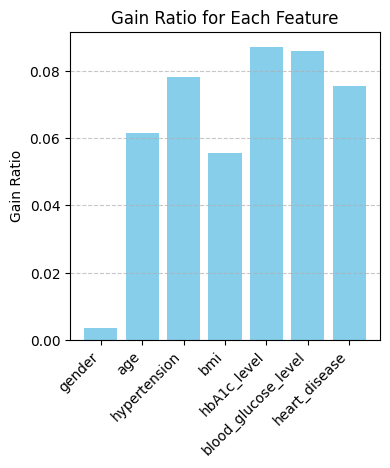

In [29]:

# Plotting the histogram
plt.figure(figsize=(4, 4))
plt.bar(gain_ratios.keys(), gain_ratios.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Gain Ratio')
plt.title('Gain Ratio for Each Feature')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [16]:
#applying the grid search and five fold cross validation to get the optimized hyper parameters

## the hyperparameters for svm algorithm  

## creating is the model 
# Step 2: Define the SVM model
svm_model = SVC(random_state=42)
param_grid = {
  'C': list(range(5, 15)),  # Regularization parameter
    'kernel': ['linear', 'poly', 'rbf'],  # Kernel type: linear, rbf (Gaussian), polynomial
    'gamma': [ 0.1, 0.2, 0.5, 1],  # Kernel coefficient
    'degree': [2, 3, 4, 5]  
}

svm_model = GridSearchCV(svm_model, param_grid=param_grid, cv=3, verbose=1, n_jobs=-1)
svm_model.fit(X_train, y_train)

# Get the best parameters and score
print("Best Parameters:", svm_model.best_params_)
print("Best Score:", svm_model.best_score_)


Fitting 3 folds for each of 480 candidates, totalling 1440 fits
Best Parameters: {'C': 14, 'degree': 5, 'gamma': 1, 'kernel': 'poly'}
Best Score: 0.9033298662928292


In [17]:
 ## accuracy, precision, recall, and the F1-score.
y_pred = svm_model.predict(X_test)


In [18]:
cm = confusion_matrix(y_test, y_pred) 
cm

array([[14673,  1839],
       [  160,  1587]], dtype=int64)

In [19]:
accuracy=accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.8905197436880442
Precision: 0.46322241681260945
Recall: 0.9084144247281053
F1-score: 0.6135704620143051
